### Нестерова Дарья, почта - dnenapep@yandex.ru

# Классификация ботов 


## стартовая схема решения


изучаю данные -> отбираю события только внутри окна -> строю разные признаки (временные, категориальные, поведенческие в целом) -> валидация по времени -> обучаю модели -> оптимизация score -> submission.csv 




In [87]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from metric import precision_at_recall   # беру реализацию из файла
from sklearn.preprocessing import OneHotEncoder
import sys

from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv(DATA_DIR / "events.csv.gz", compression="gzip", parse_dates=["event_ts"])

In [2]:
print("train", train.shape)
print("test", test.shape)
print("events", events.shape)

train (11091, 5)
test (4909, 4)
events (328905, 14)


In [3]:
print(train["target"].value_counts())
print()
print(train["target"].value_counts(normalize=True).round(3))

target
0    10192
1      899
Name: count, dtype: int64

target
0    0.919
1    0.081
Name: proportion, dtype: float64


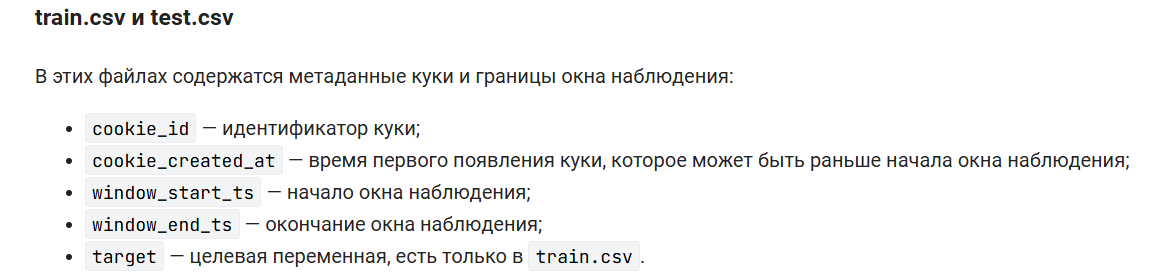

In [4]:
train.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [5]:
test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


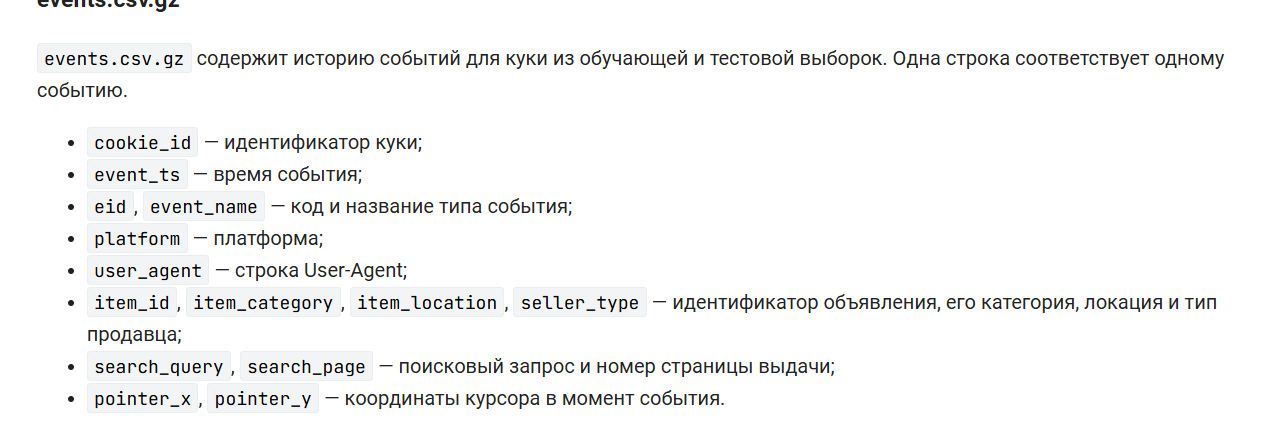

In [6]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


## Осмотреться

Прежде чем считать агрегаты, стоит посмотреть на данные: какие типы событий бывают, что
лежит в `platform` и `user_agent`, где пропуски, всё ли уникально.

In [7]:
print(events.event_name.value_counts(), '\n')
print(events.platform.value_counts(), '\n')
print('пропуски по колонкам:')
print(events.isna().mean().round(3))

event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64 

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64 

пропуски по колонкам:
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64


In [8]:
tr_dup = train.duplicated().sum()
te_dup = test.duplicated().sum()
print("дубликаты в train:", tr_dup)
print("дубликаты в test:", te_dup)

дубликаты в train: 0
дубликаты в test: 0


## Быстрая проверка временных окон

смотрю уникальные окна, сколько разных куки в них, смотрю в трейне долю ботов (mean)

In [9]:
print("Окна train:")
print(train.groupby(["window_start_ts", "window_end_ts"])["target"].agg(["size", "mean"]))

print("\nОкна test:")
print(test.groupby(["window_start_ts", "window_end_ts"]).size())

print("\nTrain = Test cookie:", len(set(train["cookie_id"]) & set(test["cookie_id"])))

Окна train:
                               size      mean
window_start_ts window_end_ts                
2026-04-06      2026-04-07      772  0.088083
2026-04-07      2026-04-08      797  0.074028
2026-04-08      2026-04-09      834  0.083933
2026-04-09      2026-04-10      902  0.073171
2026-04-10      2026-04-11      912  0.089912
2026-04-11      2026-04-12      896  0.088170
2026-04-12      2026-04-13      817  0.082007
2026-04-13      2026-04-14      843  0.062871
2026-04-14      2026-04-15      826  0.084746
2026-04-15      2026-04-16      801  0.081149
2026-04-16      2026-04-17      740  0.081081
2026-04-17      2026-04-18      713  0.092567
2026-04-18      2026-04-19      606  0.085809
2026-04-19      2026-04-20      632  0.066456

Окна test:
window_start_ts  window_end_ts
2026-04-20       2026-04-21       652
2026-04-21       2026-04-22       628
2026-04-22       2026-04-23       637
2026-04-23       2026-04-24       660
2026-04-24       2026-04-25       760
2026-04-25       20

тест начинается позже train, поэтому мб оставить **последние дни train как validation**

**Что поняла:** Окна train и test - по суткам каждое, train 06–20 апреля, test 20–27 апреля. В train на каждый день приходится около 600-900 cookie, доля ботов ровная, 6-9%, без скачков -> классы распределены по дням одинаково -> валидация по последним дням норм и не будет ошибок. В test счётчик cookie за день такой же (650-810), то есть объёмы сопоставимы. Пересечений cookie между train и test нет (ну мало ли, случайно)


# Подготовка событий

Признаки считаю только по событиям внутри окна. Это требование из условия, а не рекомендация.

Для каждой cookie мы берём только такие события:

```text
window_start_ts <= event_ts < window_end_ts
```

Даже если у этой cookie в `events.csv.gz` есть события позже, они не должны попасть в признаки

In [10]:
#нормирую платформы
events["platform"] = events["platform"].str.strip().str.lower().replace({
    "iphone": "ios",
    "desktop": "web",
})

def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print("событий в трейн:", len(ev_tr), "событий в тесте:", len(ev_te))

событий в трейн: 198436 событий в тесте: 89690


In [11]:
cat_cols = ev_tr.select_dtypes(include=['object', 'string']).columns

In [12]:
for col in cat_cols:
    ev_tr[col] = ev_tr[col].fillna('NA')
    ev_te[col] = ev_te[col].fillna('NA')

In [13]:
ev_tr.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,window_start_ts,window_end_ts
0,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NA,NaN,675.0,276.0,2026-04-13,2026-04-14
1,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NA,пылесос dyson,2.0,NaN,NaN,2026-04-08,2026-04-09
2,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NA,костюм мужской,2.0,NaN,NaN,2026-04-12,2026-04-13
4,ck_f80d85f038cdacee,2026-04-11 16:08:12,200,item_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1000845.0,bytovaya_tehnika,sankt-peterburg,private,NA,NaN,NaN,NaN,2026-04-11,2026-04-12
5,ck_e4f046f721d10f81,2026-04-10 16:50:05,200,item_view,ios,Mozilla/5.0 (iPhone; CPU iPhone OS 15_2 like M...,1055188.0,telefony,ekaterinburg,pro,NA,NaN,NaN,NaN,2026-04-10,2026-04-11


# 1 самые простые признаки


- сколько всего было событий
- сколько уникальных значений было по нескольким полям (списочек написала)
- сколько различных часов пользователь был активен (куки была активна)

  p.s. я имею ввиду количество разного времени событий у одной куки. если проще, я смотрю, события происходили прмерно в одно и то же время или в разное (поэтому беру именно часы)

In [14]:
def basic_features(e):
    g = e.groupby("cookie_id") #группипрую соблытие по куки

    f = g.size().rename("n_events").to_frame() #сколько событий у каждой куки

    unique_columns = [
        "item_id",
        "item_category",
        "item_location",
        "search_query",
        "seller_type",
        "platform",
    ]
    for col in unique_columns:
        f[f"nuniq_{col}"] = g[col].nunique()

     # сколько разных часов и дней была активна cookie
    # эти признаки беру по сути прямо из event_ts
    f["n_active_hours"] = g["event_ts"].apply(lambda s: s.dt.floor("h").nunique())
    f["n_active_days"] = g["event_ts"].apply(lambda s: s.dt.date.nunique())
    return f

In [15]:
tr_bas = basic_features(ev_tr)
te_bas = basic_features(ev_te)

print("Размер на train:", tr_bas.shape)

Размер на train: (11091, 9)


In [16]:
test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


In [17]:
tr_bas.head(10)

,n_events,nuniq_item_id,nuniq_item_category,nuniq_item_location,nuniq_search_query,nuniq_seller_type,nuniq_platform,n_active_hours,n_active_days
cookie_id,,,,,,,,,
ck_000c95f1408dcb00,16,9,3,9,4,3,1,6,1
ck_000e8c52636e3bec,34,20,5,13,9,3,1,3,1
ck_0010e31baa4a1fb7,16,8,4,5,5,3,1,8,1
ck_0010ec3874fb5378,74,31,3,20,9,3,1,11,1
ck_001722063b94cae0,15,8,4,10,5,3,1,2,1
ck_0029775566c17ac5,6,2,3,4,3,2,1,3,1
ck_0030c4974c775756,10,5,3,5,3,3,1,2,1
ck_0032c08d8987d0ad,52,27,7,11,18,3,1,5,1
ck_0037dcb6ec6b40c4,1,1,1,1,1,1,1,1,1


### ИТОГ ТАБЛИЦЫ tr_bas,te_bas

## 2 Сколько было каждого типа события

In [18]:
def event_c_features(e):
    #для всех куки сколько раз встречался каждый тип события
    counts = pd.crosstab(e["cookie_id"], e["event_name"])
    counts.columns = [f"cnt_{name}" for name in counts.columns]
    return counts

In [19]:
tr_evc = event_c_features(ev_tr)
te_evc = event_c_features(ev_te)
print("Размер на train:", tr_evc.shape)

Размер на train: (11091, 9)


In [20]:
tr_evc.head()

,cnt_contact_chat_open,cnt_contact_message_sent,cnt_contact_phone_show,cnt_favorite_add,cnt_item_view,cnt_login,cnt_photo_swipe,cnt_search_results_view,cnt_seller_page_view
cookie_id,,,,,,,,,
ck_000c95f1408dcb00,0,0,0,0,11,0,1,3,1
ck_000e8c52636e3bec,0,0,1,4,11,1,5,9,3
ck_0010e31baa4a1fb7,0,0,0,2,7,1,1,4,1
ck_0010ec3874fb5378,0,0,0,10,25,1,14,20,4
ck_001722063b94cae0,0,0,1,0,8,0,1,5,0


### ИТОГ ТАБЛИЦЫ tr_evс, te_evc

## 3 Временные признаки

Мне кажется, что куки людей и ботов во времени ведут себя по-разному. Смотрю на всякие врмемена (в секундах): сколько куки активна, когда первая и последняя активности после начала окна 

Потом на интервалы между событиями (человек вряд ли может совершать по 100 событий в минуту, например)

In [21]:
def event_position(e, rows):
    g = e.groupby("cookie_id")
    first = g["event_ts"].min()
    last = g["event_ts"].max()

    window = rows.set_index("cookie_id") # делаю колонку cookie_id индексом, убирая её из колонок
    f = pd.DataFrame(index=first.index)

    # сколько куки была активна
    f["event_sec"] = (last - first).dt.total_seconds()
    # через сколько секунд после начала окна произошло первое событие
    f["start_sec"] = (first - window.loc[first.index, "window_start_ts"]).dt.total_seconds()
    # за скок секунд до конца окна последнее событие
    f["toend_sec"] = (window.loc[last.index, "window_end_ts"] - last).dt.total_seconds()

    # доля событий, которые произошли ночью (с 00 до 6)
    is_night = e["event_ts"].dt.hour < 6
    f["night_ev"] = (is_night.groupby(e["cookie_id"]).mean())
    return f

In [22]:
tr_position = event_position(ev_tr, train)
te_position = event_position(ev_te, test)
tr_position.head()

,event_sec,start_sec,toend_sec,night_ev
cookie_id,,,,
ck_000c95f1408dcb00,30117.0,53394.0,2889.0,0.000000
ck_000e8c52636e3bec,6681.0,23160.0,56559.0,0.000000
ck_0010e31baa4a1fb7,42376.0,42798.0,1226.0,0.000000
ck_0010ec3874fb5378,57064.0,7703.0,21633.0,0.216216
ck_001722063b94cae0,4118.0,65229.0,17053.0,0.000000


Хочу посчитать интервалы между событиями у одной куки

In [23]:
def interval(e):
    # сортирую события каждой cookie по времени
    e = e.sort_values(["cookie_id", "event_ts"])
    intervals = (e.groupby("cookie_id")["event_ts"].diff().dt.total_seconds())  # время между соседними событиями
    return pd.DataFrame({"cookie_id": e["cookie_id"],"interval": intervals})

In [24]:
tr_interval = interval(ev_tr)
te_interval = interval(ev_te)
tr_interval.head()

,cookie_id,interval
189443,ck_000c95f1408dcb00,NaN
47919,ck_000c95f1408dcb00,23.0
143776,ck_000c95f1408dcb00,3604.0
134951,ck_000c95f1408dcb00,26.0
155957,ck_000c95f1408dcb00,58.0


In [25]:
tr_interval.shape

(198436, 2)

Но это просто инервалы, не думаю, что они информативны. Хочу посчитать всякие стастистики для них

In [26]:
def interval_stat(interval):
    f = (interval.groupby("cookie_id")["interval"].agg(["mean", "median", "std", "min", "max"]))
    f.columns = [
        "interv_mean",
        "interv_median",
        "interv_std",
        "interv_min",
        "interv_max"
    ]
    # доля микро-интервальчиков
    f["fast_inter_ratio"] = interval.groupby("cookie_id")["interval"].agg(lambda s: (s.dropna() < 2).mean())
    return f

In [27]:
tr_interval = interval_stat(tr_interval)
te_interval = interval_stat(te_interval)

In [28]:
tr_interval.head()

,interv_mean,interv_median,interv_std,interv_min,interv_max,fast_inter_ratio
cookie_id,,,,,,
ck_000c95f1408dcb00,2007.800000,58.0,3080.553503,17.0,7733.0,0.000000
ck_000e8c52636e3bec,202.454545,23.0,774.305983,0.0,4257.0,0.090909
ck_0010e31baa4a1fb7,2825.066667,334.0,3107.706813,10.0,8243.0,0.000000
ck_0010ec3874fb5378,781.698630,32.0,1984.404925,0.0,8567.0,0.027397
ck_001722063b94cae0,294.142857,175.0,427.831357,2.0,1447.0,0.000000


In [29]:
tr_interval.shape

(11091, 6)

In [30]:
tr_time = tr_position.join(tr_interval)
te_time = te_position.join(te_interval)

print("Размер временных признаков train:", tr_time.shape)

Размер временных признаков train: (11091, 10)


In [31]:
tr_time.head()

,event_sec,start_sec,toend_sec,night_ev,interv_mean,interv_median,interv_std,interv_min,interv_max,fast_inter_ratio
cookie_id,,,,,,,,,,
ck_000c95f1408dcb00,30117.0,53394.0,2889.0,0.000000,2007.800000,58.0,3080.553503,17.0,7733.0,0.000000
ck_000e8c52636e3bec,6681.0,23160.0,56559.0,0.000000,202.454545,23.0,774.305983,0.0,4257.0,0.090909
ck_0010e31baa4a1fb7,42376.0,42798.0,1226.0,0.000000,2825.066667,334.0,3107.706813,10.0,8243.0,0.000000
ck_0010ec3874fb5378,57064.0,7703.0,21633.0,0.216216,781.698630,32.0,1984.404925,0.0,8567.0,0.027397
ck_001722063b94cae0,4118.0,65229.0,17053.0,0.000000,294.142857,175.0,427.831357,2.0,1447.0,0.000000


### ИТОГ ТАБЛИЦЫ С ПРИЗНАКАМИ tr_time, te_time

## 4 Числовые признаки из событий

у меня есть числа - координаты курсора и номер страницы поиска

Для них посчитаю статиститики: среднее, стандартное отклонение и число уникальных значений (ну, например, человек обычно чаще двигает курсором, чем бот)

In [32]:
def num_f(e):
    g = e.groupby("cookie_id")
    f = pd.DataFrame(index=g.size().index)
    for col in ["search_page", "pointer_x", "pointer_y"]:
        stats = g[col].agg(["mean", "std", "nunique"])
        stats.columns = [f"{col}_{c}" for c in stats.columns]
        f = f.join(stats)
    return f

In [33]:
tr_num = num_f(ev_tr)
te_num = num_f(ev_te)

In [34]:
print("Размер числовых признаков train:", tr_num.shape)

Размер числовых признаков train: (11091, 9)


In [35]:
tr_num.head()

,search_page_mean,search_page_std,search_page_nunique,pointer_x_mean,pointer_x_std,pointer_x_nunique,pointer_y_mean,pointer_y_std,pointer_y_nunique
cookie_id,,,,,,,,,
ck_000c95f1408dcb00,2.333333,1.527525,3,1160.750000,494.980875,16,590.937500,338.074640,16
ck_000e8c52636e3bec,3.777778,3.527668,6,903.193548,561.544146,31,433.709677,277.719426,31
ck_0010e31baa4a1fb7,1.000000,0.000000,1,759.625000,501.890941,16,636.625000,361.434157,15
ck_0010ec3874fb5378,1.800000,1.196486,4,NaN,NaN,0,NaN,NaN,0
ck_001722063b94cae0,1.400000,0.547723,2,NaN,NaN,0,NaN,NaN,0


### ИТОГ ТАБЛИЦЫ С ПРИЗНАКАМИ tr_num, te_num

## 5 пользовательские признаки

ищу признаки  программного клиента: например, слова python, curl, headless

это, на мой взгляд, может быть сигналом к боту

In [36]:
def user_agent_f(e):
    f = pd.DataFrame(index=e.groupby("cookie_id").size().index)
    ua = e["user_agent"].astype(str).str.lower() #к нижнему регистру
    pats = {
        "headless": "headless",
        "python": "python",
        "curl": "curl",
        "linux": "linux",
        "windows": "windows",
        "mac": "macintosh",
        "mobile": "mobile",
        "android": "android",
        "iphone": "iphone",
        "safari": "safari",
        "firefox": "firefox",
        "yabrowser": "yabrowser",
    }
    for name, pat in pats.items():
        mask = ua.str.contains(pat, regex=False)
        stats = mask.groupby(e["cookie_id"]).agg(["sum", "mean"])
        f[f"ua_{name}_cnt"] = stats["sum"]
        f[f"ua{name}_ratio"] = stats["mean"]
    return f

In [37]:
tr_ua = user_agent_f(ev_tr)
te_ua = user_agent_f(ev_te)

In [38]:
tr_ua.shape

(11091, 24)

In [39]:
tr_ua.head()

,ua_headless_cnt,uaheadless_ratio,ua_python_cnt,uapython_ratio,ua_curl_cnt,uacurl_ratio,ua_linux_cnt,ualinux_ratio,ua_windows_cnt,uawindows_ratio,...,ua_android_cnt,uaandroid_ratio,ua_iphone_cnt,uaiphone_ratio,ua_safari_cnt,uasafari_ratio,ua_firefox_cnt,uafirefox_ratio,ua_yabrowser_cnt,uayabrowser_ratio
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_000c95f1408dcb00,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,...,0,0.0,0,0.0,16,1.0,0,0.0,0,0.0
ck_000e8c52636e3bec,0,0.0,0,0.0,0,0.0,0,0.0,34,1.0,...,0,0.0,0,0.0,0,0.0,34,1.0,0,0.0
ck_0010e31baa4a1fb7,0,0.0,0,0.0,0,0.0,0,0.0,16,1.0,...,0,0.0,0,0.0,16,1.0,0,0.0,16,1.0
ck_0010ec3874fb5378,0,0.0,0,0.0,0,0.0,0,0.0,74,1.0,...,0,0.0,0,0.0,74,1.0,0,0.0,74,1.0
ck_001722063b94cae0,0,0.0,0,0.0,0,0.0,15,1.0,0,0.0,...,15,1.0,0,0.0,15,1.0,0,0.0,0,0.0


### ИТОГ ТАБЛИЦЫ С ПРИЗНАКМИ tr_ua, te_ua

## 6 Признаки движения мыши

В данных есть pointer_x и pointer_y (уже затрагиввла раньше) Использую их как дополнительные признаки:

- средняя длина перемещения курсора
- доля практически нулевых перемещений
- количество наблюдений курсора

Рассматриваю такие признаки, потому что курсор, управляемый человеком и курсор, управляемый ботом будет по-другому двигаться

In [40]:
def point_f(e):
    pointer = e.dropna(subset=["pointer_x", "pointer_y"]).copy()
    f = pd.DataFrame(index=e.groupby("cookie_id").size().index)

    if pointer.empty:
        return f
    pointer = pointer.sort_values(["cookie_id", "event_ts"])
    dx = pointer.groupby("cookie_id")["pointer_x"].diff()
    dy = pointer.groupby("cookie_id")["pointer_y"].diff()
    distance = np.sqrt(dx ** 2 + dy ** 2)

    f["p_dist_mean"] = distance.groupby(pointer["cookie_id"]).mean()
    f["p_dist_zero"] = distance.groupby(pointer["cookie_id"]).agg(lambda s: (s.dropna() == 0).mean())
    f["p_n"] = pointer.groupby("cookie_id").size()
    return f

In [41]:
tr_point = point_f(ev_tr)
te_point = point_f(ev_te)

In [42]:
tr_point.shape

(11091, 3)

In [43]:
tr_point.head()

,p_dist_mean,p_dist_zero,p_n
cookie_id,,,
ck_000c95f1408dcb00,646.201297,0.0,16.0
ck_000e8c52636e3bec,786.870245,0.0,31.0
ck_0010e31baa4a1fb7,772.326478,0.0,16.0
ck_0010ec3874fb5378,NaN,NaN,NaN
ck_001722063b94cae0,NaN,NaN,NaN


## 7 Самый частый вариант (категориальных признаков)

Для каждой куки сохраню наиболее часто встречающиеся:

- платформу
- категорию объявления
- локацию
- тип продавца

In [44]:
def cat_f(e):
    f = pd.DataFrame(index=e.groupby("cookie_id").size().index)
    e = e.copy()
    e["platform_norm"] = e["platform"].str.lower().replace({"iphone": "ios"})
    for col, name in [ ("platform_norm", "mode_platform"),
        ("item_category", "mode_category"),
        ("item_location", "mode_location"),
        ("seller_type", "mode_seller")]:
        mode = e.groupby("cookie_id")[col].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else "NA")
        f[name] = mode
    return f

In [45]:
tr_cat = cat_f(ev_tr)
te_cat = cat_f(ev_te)

In [46]:
tr_cat.shape

(11091, 4)

In [47]:
tr_cat.head()

,mode_platform,mode_category,mode_location,mode_seller
cookie_id,,,,
ck_000c95f1408dcb00,web,mebel,samara,private
ck_000e8c52636e3bec,web,uslugi,izhevsk,private
ck_0010e31baa4a1fb7,web,bytovaya_tehnika,barnaul,private
ck_0010ec3874fb5378,web,noutbuki,kemerovo,private
ck_001722063b94cae0,android,kvartiry_prodazha,sankt-peterburg,NA


## 8 Метапризнаки всякие


- cookie_age_days	- сколько дней cookie существовала к началу окна
- created_hour - час создания cookie
- created_dow	- день недели создания
- window_dow - день недели начала окна
- window_day - день месяца начала окна
- events_per_active_hour - интенсивность событий по активным часам
- events_per_day - интенсивность событий по активным дням

In [48]:
def meta_features(rows, basic):
    rows_indexed = rows.set_index("cookie_id")
    f = pd.DataFrame(index=basic.index)

    f["cookie_age_days"] = (rows_indexed.loc[f.index, "window_start_ts"]- rows_indexed.loc[f.index, "cookie_created_at"]).dt.total_seconds() / 86400
    f["created_hour"] = (rows_indexed.loc[f.index, "cookie_created_at"].dt.hour)
    f["created_dow"] = (rows_indexed.loc[f.index, "cookie_created_at"].dt.dayofweek)
    f["window_dow"] = (rows_indexed.loc[f.index, "window_start_ts"].dt.dayofweek)
    f["window_day"] = (rows_indexed.loc[f.index, "window_start_ts"].dt.day)

    # нормирую колво событий на время активности
    f["events_per_active_hour"] = (basic["n_events"]/ basic["n_active_hours"].replace(0, np.nan))

    f["events_per_day"] = (basic["n_events"]/ basic["n_active_days"].replace(0, np.nan))
    return f


In [49]:
tr_meta = meta_features(train, tr_bas)
te_meta = meta_features(test, te_bas)

In [50]:
tr_meta.shape

(11091, 7)

In [51]:
tr_meta.head()

,cookie_age_days,created_hour,created_dow,window_dow,window_day,events_per_active_hour,events_per_day
cookie_id,,,,,,,
ck_000c95f1408dcb00,232.960440,0,4,6,19,2.666667,16.0
ck_000e8c52636e3bec,25.480150,12,3,1,7,11.333333,34.0
ck_0010e31baa4a1fb7,82.715069,6,3,2,15,2.000000,16.0
ck_0010ec3874fb5378,102.395208,14,2,0,6,6.727273,74.0
ck_001722063b94cae0,0.668785,7,3,4,10,7.500000,15.0


# объединяю все признаки в одну таблицу



In [52]:
train_features = tr_bas.copy()
train_features = train_features.join(tr_evc, how="left")
train_features = train_features.join(tr_time, how="left")
train_features = train_features.join(tr_num, how="left")
train_features = train_features.join(tr_ua, how="left")
train_features = train_features.join(tr_point, how="left")
train_features = train_features.join(tr_cat, how="left")
train_features = train_features.join(tr_meta, how="left")

In [53]:
test_features = te_bas.copy()
test_features = test_features.join(te_evc, how="left")
test_features = test_features.join(te_time, how="left")
test_features = test_features.join(te_num, how="left")
test_features = test_features.join(te_ua, how="left")
test_features = test_features.join(te_cat, how="left")
test_features = test_features.join(te_point, how="left")
test_features = test_features.join(te_meta, how="left")

In [54]:
train_features = train_features.reset_index()
test_features = test_features.reset_index()

In [55]:
print("Размер итоговых признаков train:", train_features.shape)
print("Размер итоговых признаков test:", test_features.shape)

Размер итоговых признаков train: (11091, 76)
Размер итоговых признаков test: (4909, 76)


In [56]:
train_features.head()

,cookie_id,n_events,nuniq_item_id,nuniq_item_category,nuniq_item_location,nuniq_search_query,nuniq_seller_type,nuniq_platform,n_active_hours,n_active_days,...,mode_category,mode_location,mode_seller,cookie_age_days,created_hour,created_dow,window_dow,window_day,events_per_active_hour,events_per_day
0,ck_000c95f1408dcb00,16,9,3,9,4,3,1,6,1,...,mebel,samara,private,232.960440,0,4,6,19,2.666667,16.0
1,ck_000e8c52636e3bec,34,20,5,13,9,3,1,3,1,...,uslugi,izhevsk,private,25.480150,12,3,1,7,11.333333,34.0
2,ck_0010e31baa4a1fb7,16,8,4,5,5,3,1,8,1,...,bytovaya_tehnika,barnaul,private,82.715069,6,3,2,15,2.000000,16.0
3,ck_0010ec3874fb5378,74,31,3,20,9,3,1,11,1,...,noutbuki,kemerovo,private,102.395208,14,2,0,6,6.727273,74.0
4,ck_001722063b94cae0,15,8,4,10,5,3,1,2,1,...,kvartiry_prodazha,sankt-peterburg,NA,0.668785,7,3,4,10,7.500000,15.0


# Валидация

Поскольку test идёт после train по времени, в качестве validation оставлю последние два дня train - **16-19 апреля**. Обучение будет на более ранних днях

In [57]:
train_features = train_features.merge(
    train[["cookie_id", "target", "window_start_ts"]],
    on="cookie_id",
    how="inner"
)

y = train_features["target"].astype(int)
train_mask = train_features["window_start_ts"] < pd.Timestamp("2026-04-16")
valid_mask = ~train_mask

print("Train rows:", train_mask.sum())
print("Validation rows:", valid_mask.sum())
print("доля ботов в train:", round(y[train_mask].mean(), 3))
print("доля ботов в valid:", round(y[valid_mask].mean(), 3))

Train rows: 8400
Validation rows: 2691
доля ботов в train: 0.081
доля ботов в valid: 0.082


In [58]:
X = train_features.drop(columns=["target", "window_start_ts", "cookie_id"])
cat_cols = [c for c in X.columns if c.startswith("mode_")]
for col in cat_cols:
    X[col] = X[col].astype(str)
cat_idx = [X.columns.get_loc(col) for col in cat_cols]

print("Всего:", X.shape[1])
print("Категориальных:", cat_cols)

Всего: 75
Категориальных: ['mode_platform', 'mode_category', 'mode_location', 'mode_seller']


## обучаю RandomForest
Random Forest не умеет напрямую работать со строковыми категориями, поэтому для него отдельно кодирую cat_cols через One-Hot Encoding


In [59]:
num_cols = [col for col in X.columns if col not in cat_cols]

In [60]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X.loc[train_mask, cat_cols])
X_valid_cat = encoder.transform(X.loc[valid_mask, cat_cols])

In [61]:
X_train_num = X.loc[train_mask, num_cols].to_numpy()
X_valid_num = X.loc[valid_mask, num_cols].to_numpy()

In [62]:
X_train_rf = np.hstack([X_train_num,X_train_cat])
X_valid_rf = np.hstack([X_valid_num,X_valid_cat])

In [63]:
model_rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=RANDOM_STATE
)


model_rf.fit(
    X_train_rf,
    y.loc[train_mask]
)

RandomForestClassifier(min_samples_leaf=3, n_estimators=300, random_state=42)

# качество на validation

In [64]:
valid_score_rf = model_rf.predict_proba(X_valid_rf)[:, 1]
p_at_r_rf = precision_at_recall(y.loc[valid_mask],valid_score_rf)

print("PR-AUC:", round(average_precision_score(y.loc[valid_mask], valid_score_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y.loc[valid_mask], valid_score_rf), 4))
print("Precision при Recall >= 70%:", round(p_at_r_rf, 4))

PR-AUC: 0.6944
ROC-AUC: 0.896
Precision при Recall >= 70%: 0.6364


#  Обучаю  catboost



In [65]:
#оценка качество модели на валидации
class PrecisionAtRecall70:
    def is_max_optimal(self):
        return True

    def evaluate(self, approxes, target, weight):
        value = precision_at_recall(
            target,
            approxes[0],
            recall=0.70,
        )
        return value, 1.0

    def get_final_error(self, error, weight):
        return error

model = CatBoostClassifier(
    iterations=10000,
    # depth=6,
    # learning_rate=0.05,
    loss_function="Logloss",
    eval_metric=PrecisionAtRecall70(),
    # l2_leaf_reg=5,
    # random_strength=1,
    random_seed=RANDOM_STATE,
    # auto_class_weights='Balanced',
    verbose=False,
)

model.fit(
    X.loc[train_mask],
    y.loc[train_mask],
    cat_features=cat_idx,
    eval_set=(X.loc[valid_mask], y.loc[valid_mask]),
    early_stopping_rounds=100,
    verbose=100,
)

Learning rate set to 0.019688
0:	learn: 0.1559332	test: 0.1658391	best: 0.1658391 (0)	total: 250ms	remaining: 41m 37s
100:	learn: 0.6676017	test: 0.5767790	best: 0.5877863 (96)	total: 13.3s	remaining: 21m 43s
200:	learn: 0.7727273	test: 0.6224900	best: 0.6224900 (200)	total: 26.9s	remaining: 21m 50s
300:	learn: 0.8227194	test: 0.6416667	best: 0.6416667 (260)	total: 40s	remaining: 21m 28s
400:	learn: 0.8670310	test: 0.6540084	best: 0.6609442 (360)	total: 53.3s	remaining: 21m 15s
500:	learn: 0.8949343	test: 0.6936937	best: 0.6936937 (489)	total: 1m 6s	remaining: 21m 2s
600:	learn: 0.9161905	test: 0.7031963	best: 0.7031963 (591)	total: 1m 19s	remaining: 20m 46s
700:	learn: 0.9503968	test: 0.6968326	best: 0.7064220 (604)	total: 1m 32s	remaining: 20m 31s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7064220183
bestIteration = 604

Shrink model to first 605 iterations.


CatBoostClassifier(eval_metric=<__main__.PrecisionAtRecall70 object at 0x00000205E14E9FD0>, iterations=10000, loss_function='Logloss', random_seed=42, verbose=False)

# качество на validation

In [66]:
valid_score = model.predict_proba(X.loc[valid_mask])[:, 1]
p_at_r = precision_at_recall(y.loc[valid_mask], valid_score)

print("PR-AUC:", round(average_precision_score(y.loc[valid_mask], valid_score), 4))
print("ROC-AUC:", round(roc_auc_score(y.loc[valid_mask], valid_score), 4))
print("Precision при Recall >= 70%:", round(p_at_r, 4))

PR-AUC: 0.7347
ROC-AUC: 0.9266
Precision при Recall >= 70%: 0.7064


# важность признаков

In [67]:
imp = pd.Series(model.get_feature_importance(),index=X.columns).sort_values(ascending=False)
imp.head(10)

interv_median             11.988235
pointer_x_std             10.390649
nuniq_item_category        7.316811
p_dist_mean                5.901305
nuniq_item_location        5.680732
interv_min                 3.903124
search_page_mean           3.236300
cookie_age_days            3.180753
events_per_active_hour     2.746329
cnt_favorite_add           2.455879
dtype: float64

## околоконстантные признаки

In [68]:
def near_constant(df, threshold=0.99):
    near_const = []
    for col in df.columns:
        top_r = (df[col].value_counts(normalize=True, dropna=False).iloc[0])
        if top_r >= threshold:
            near_const.append(col)
    return near_const

In [69]:
const_cols = near_constant(X.loc[train_mask],threshold=0.99)
print("околоконстантных признаков:", len(const_cols))
print(const_cols)

околоконстантных признаков: 6
['nuniq_platform', 'n_active_days', 'ua_python_cnt', 'uapython_ratio', 'ua_curl_cnt', 'uacurl_ratio']


In [70]:
X_no_const = X.drop(columns=const_cols).copy()
cat_cols= [col for col in cat_cols if col in X_no_const.columns] # Обновляю список категориальных признаков после удаления
print("Признаков после дропа:", X_no_const.shape[1])
print("Категориальных:", len(cat_cols))

Признаков после дропа: 69
Категориальных: 4


### Обучу катбуст, удалив околоконстантные, посмотрю, насколько это вообще влияет в этой задаче

In [71]:
cat_idx = [X_no_const.columns.get_loc(col) for col in cat_cols]

In [72]:
model = CatBoostClassifier(
    iterations=10000,
    # depth=6,
    # learning_rate=0.05,
    loss_function="Logloss",
    eval_metric=PrecisionAtRecall70(),
    # l2_leaf_reg=5,
    # random_strength=1,
    random_seed=RANDOM_STATE,
    # auto_class_weights="Balanced",
    verbose=False,
)

model.fit(
    X_no_const.loc[train_mask],
    y.loc[train_mask],
    cat_features=cat_idx,
    eval_set=(X_no_const.loc[valid_mask], y.loc[valid_mask]),
    early_stopping_rounds=100,
    verbose=100,
)

Learning rate set to 0.019688
0:	learn: 0.1017195	test: 0.0886279	best: 0.0886279 (0)	total: 114ms	remaining: 19m
100:	learn: 0.6732673	test: 0.5682657	best: 0.5724907 (97)	total: 13.1s	remaining: 21m 23s
200:	learn: 0.7747164	test: 0.6609442	best: 0.6609442 (200)	total: 26.5s	remaining: 21m 32s
300:	learn: 0.8321799	test: 0.6968326	best: 0.6968326 (277)	total: 39.6s	remaining: 21m 15s
400:	learn: 0.8736264	test: 0.6936937	best: 0.7013575 (360)	total: 52.9s	remaining: 21m 5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7013574661
bestIteration = 360

Shrink model to first 361 iterations.


CatBoostClassifier(eval_metric=<__main__.PrecisionAtRecall70 object at 0x00000205DF2EAFD0>, iterations=10000, loss_function='Logloss', random_seed=42, verbose=False)

In [73]:
valid_score = model.predict_proba(X_no_const.loc[valid_mask])[:, 1]
p_at_r = precision_at_recall(y.loc[valid_mask], valid_score)

print("PR-AUC:", round(average_precision_score(y.loc[valid_mask], valid_score), 4))
print("ROC-AUC:", round(roc_auc_score(y.loc[valid_mask], valid_score), 4))
print("Precision при Recall >= 70%:", round(p_at_r, 4))

PR-AUC: 0.731
ROC-AUC: 0.9249
Precision при Recall >= 70%: 0.7014


**Итог**: я вижу, что качество упало, значит, в этой задаче это излишне, в финальную модель эти изменения подавать не буду

## топы признаков на catboost 

Поскольку я решила не удалять околоконстантные признаки, у меня их 75. Чуть выше я смоотрела на важность признаков. Теперь хочу попробовать отобрать топ-n и обучить на них модель. Наилучшее n буду сейчас искать перебором

Проверю несколько размеров набора признаков:

- top-25
- top-35
- ...
- top-75

p.s.чтобы побысрее это все дело училось, поставила меньше итераций у catboost (3000)

In [74]:
X = train_features.drop(columns=["target", "window_start_ts", "cookie_id"])
cat_cols = [c for c in X.columns if c.startswith("mode_")]

In [75]:
top_sizes = list(range(25, 76, 10))

best_score = -1
best_n = None
best_features = None

for n in top_sizes:
    s_cols = imp.head(n).index.tolist()
    s_cat_cols = [col for col in cat_cols if col in s_cols]
    X_train_top = X.loc[train_mask, s_cols]
    X_valid_top = X.loc[valid_mask, s_cols]
    model = CatBoostClassifier(
        iterations=3000,
        # depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric=PrecisionAtRecall70(),
        random_seed=RANDOM_STATE,
        # auto_class_weights="Balanced",
        verbose=False,
    )

    model.fit(
        X_train_top.loc[train_mask],
        y.loc[train_mask],
        cat_features=s_cat_cols,
        eval_set=(X_valid_top, y.loc[valid_mask]),
        early_stopping_rounds=100,
        verbose=False,
    )
    valid_score = model.predict_proba(X_valid_top)[:, 1]
    score = precision_at_recall(y.loc[valid_mask],valid_score)
    print(f"Top-{n}: Precision при Recall >= 70% = {score:.4f}")
  
    if score > best_score:
        best_score = score
        best_n = n
        best_features = s_cols

Top-25: Precision при Recall >= 70% = 0.7333
Top-35: Precision при Recall >= 70% = 0.7488
Top-45: Precision при Recall >= 70% = 0.7209
Top-55: Precision при Recall >= 70% = 0.7299
Top-65: Precision при Recall >= 70% = 0.7196
Top-75: Precision при Recall >= 70% = 0.7404


In [76]:
print("Лучший результат:", round(best_score, 4))
print("Оптимальное количество признаков:", best_n)

Лучший результат: 0.7488
Оптимальное количество признаков: 35


In [77]:
model = CatBoostClassifier(
    iterations=10000,
    # depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric=PrecisionAtRecall70(),
    # l2_leaf_reg=5,
    # random_strength=1,
    random_seed=RANDOM_STATE,
    # auto_class_weights="Balanced",
    verbose=False,
)

model.fit(
    X.loc[train_mask][best_features],
    y.loc[train_mask],
    cat_features=[col for col in cat_cols if col in best_features],
    eval_set=(X.loc[valid_mask][best_features], y.loc[valid_mask]),
    early_stopping_rounds=100,
    verbose=100,
)

0:	learn: 0.0821816	test: 0.0824387	best: 0.0824387 (0)	total: 84.1ms	remaining: 14m 1s
100:	learn: 0.7437500	test: 0.6553191	best: 0.6553191 (99)	total: 13.2s	remaining: 21m 32s
200:	learn: 0.8336252	test: 0.6623932	best: 0.6784141 (142)	total: 26.5s	remaining: 21m 30s
300:	learn: 0.8817006	test: 0.7064220	best: 0.7064220 (297)	total: 38.6s	remaining: 20m 43s
400:	learn: 0.9370079	test: 0.7110092	best: 0.7162791 (386)	total: 50.7s	remaining: 20m 13s
500:	learn: 0.9560878	test: 0.7289720	best: 0.7333333 (432)	total: 1m 5s	remaining: 20m 34s
600:	learn: 0.9875776	test: 0.7368421	best: 0.7368421 (592)	total: 1m 18s	remaining: 20m 23s
700:	learn: 0.9939271	test: 0.7428571	best: 0.7475728 (686)	total: 1m 31s	remaining: 20m 13s
800:	learn: 0.9979550	test: 0.7393365	best: 0.7487923 (770)	total: 1m 44s	remaining: 20m 3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7487922705
bestIteration = 770

Shrink model to first 771 iterations.


CatBoostClassifier(eval_metric=<__main__.PrecisionAtRecall70 object at 0x00000205E2EF9C50>, iterations=10000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=False)

# Финальное обучение


Теперь я воьму найденное оптимальное количество признаков и обучу CatBoost на **всём train** (гиперпараметры те, которые я выставляла раньше). Посмотрела на bestIteration, решила в финальной модели оставить 800.

После этого получу прогнозы для test и сохраню их в submission.csv, который потом прикреплю на платформу

In [78]:
X_train = train_features[best_features].copy()
X_test = test_features[best_features].copy()

In [79]:
fin_cat_cols = [col for col in cat_cols if col in best_features]

In [80]:
for c in fin_cat_cols:
    X_train[c] = X_train[c].astype(str)
    X_test[c] = X_test[c].astype(str)

cat_idx = [X_train.columns.get_loc(col) for col in fin_cat_cols]

In [81]:
final_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
)
final_model.fit(
    X_train,
    y,
    cat_features=cat_idx,
    verbose=100,
)

0:	learn: 0.6556756	total: 118ms	remaining: 1m 34s
100:	learn: 0.1400906	total: 12.8s	remaining: 1m 28s
200:	learn: 0.1205475	total: 24.9s	remaining: 1m 14s
300:	learn: 0.1086610	total: 39.2s	remaining: 1m 4s
400:	learn: 0.0983157	total: 52.8s	remaining: 52.6s
500:	learn: 0.0900893	total: 1m 5s	remaining: 39s
600:	learn: 0.0834243	total: 1m 18s	remaining: 26.1s
700:	learn: 0.0773380	total: 1m 31s	remaining: 12.9s
799:	learn: 0.0718425	total: 1m 44s	remaining: 0us


CatBoostClassifier(iterations=800, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=False)

# Создаю submission.csv

По условию здесь должны быть две колонки:

- **cookie_id** - из test.csv
- **score** - вероятность класса target = 1

In [82]:
test_score = final_model.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({"cookie_id": test_features["cookie_id"], "score": test_score})

In [83]:
# всякие проверки перед сохранением
assert submission.shape == (len(test), 2) #нормальные размеры
assert submission["cookie_id"].is_unique #уникальные объекты
assert submission["score"].notna().all() #бещ пропусков
assert submission["score"].between(0, 1).all() #все значения в пределах 0-1

In [84]:
submission.to_csv("submission.csv", index=False)

#### Также в описании задания просили сделать отдельно файл с библиотеками (+ версия питона)

In [85]:
from importlib.metadata import version
with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(
        f"# Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}\n\n"
        f"numpy=={version('numpy')}\n"
        f"pandas=={version('pandas')}\n"
        f"scikit-learn=={version('scikit-learn')}\n"
        f"catboost=={version('catboost')}\n"
    )

### описание подхода 

#### 1. Feature Engineering
-   **Агрегация:** Объединила события по `cookie_id`
-   **Признаки:**
    *   Количество событий и уникальных объектов
    *   Временные паттерны: длительность активности, интервалы между событиями, ночная активность
    *   Парсинг User-Agent
    *   Признаки движения мыши
    *   Общие статистики по cookie и временному окну

#### 2. Валидация
-   Использовала **временной сплит**: обучение на старых данных, проверка на новых (на validation взяла 16-19 апреля)

#### 3. Модели
-   Сравнила RandomForest и CatBoost
-   **Выбор:** Остановилась на **CatBoost**, тк он лучше работает с категориальными признаками и показал более высокое качество на первичном тесте

#### 4. Метрики и оптимизация
-   **Основная метрика:** Precision при Recall >= 70%
-   **Дополнительно:** PR-AUC, ROC-AUC
-   **Эксперименты:**
    *   Ручной подбор гиперпараметров
    *   Анализ важности признаков
    *   Удаление околоконстантных признаков
    *   Отбор топ-признаков (25-75 с шагом 10)
-   **Результат:** Лучшее качество на валидации показала модель на топ-35 признаках

#### 5. Финал
*   Обучение финальной модели на всем train
*   Получение предсказаний для теста и отправка на stepik

p.s. также к работе отдельно приложила текстовый файлик с описанием